# Jupyter Notebook: Data cleaning

## Step 1: Install Required Libraries

First, ensure you have the necessary libraries installed. You can install them using the following command:

`pip install pandas numpy seaborn matplotlib`

In [14]:
# Imports
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Step 2: Reading the data and removing missing values
Reading the training data

In [15]:
data_path = Path("cleaned_dataset.csv")
train_df = pd.read_csv(data_path)
train_df.head(5)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,1
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,0
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,0


Determining how many missing values each column contains. 

In [4]:
def report_missing_values(df: pd.DataFrame) -> None:
    """Print missing values count and percentage for each column."""
    for column in df.columns:
        missing_count = df[column].isnull().sum()
        total_count = len(df[column])
        missing_percentage = (missing_count / total_count) * 100
        print(f"{column} - {missing_count}, {missing_percentage:.2f}%")


report_missing_values(train_df)


Survived - 0, 0.00%
Pclass - 0, 0.00%
Name - 0, 0.00%
Sex - 0, 0.00%
Age - 0, 0.00%
SibSp - 0, 0.00%
Parch - 0, 0.00%
Embarked - 0, 0.00%


* Age has ~20% missing values. This will require handling.
* Cabin has ~77% missing values and might be excluded from analysis.
* Embarked has a small proportion of missing values. This will require handling.

#### **If you used your previous dataset in 'cleaning_data' you would not have any missing values... if you did it correctly**

Filling missing values for 'age' with the median. The median is used here instead of the mean because it is less affected by outliers. The 'age' column might have extreme values (very young or very old passengers), and the median provides a more robust measure.

In [16]:
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())


Filling missing values for 'Embarked' with the mode.
The 'Embarked' column contains categorical data. Using the mode (most frequent value) ensures that the imputed value makes sense contextually.

In [17]:
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])


Dropping 'Cabin' due to a large number of missing values
The 'Cabin' column has too many missing values to be useful for analysis. Dropping it simplifies the dataset.

### Ignore error if you used your pre-cleaned dataset, as you would have already dropped the 'Cabin' column in the cleaning process.

In [ ]:
train_df = train_df.drop(columns=["Cabin"])

Let's make sure that there are no more missing values. 

In [18]:
report_missing_values(train_df)

Survived - 0, 0.00%
Pclass - 0, 0.00%
Name - 0, 0.00%
Sex - 0, 0.00%
Age - 0, 0.00%
SibSp - 0, 0.00%
Parch - 0, 0.00%
Embarked - 0, 0.00%


## Step 3: Visualizing the data



Text(0.5, 1.0, 'Percentage of Passengers Who Survived vs Did Not Survive')

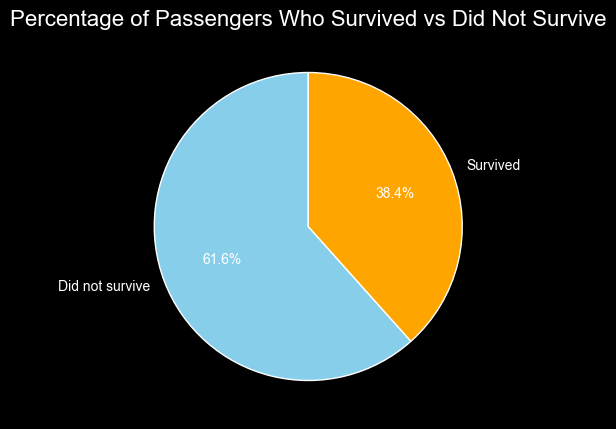

In [19]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
survival_percentages = train_df["Survived"].value_counts(normalize=True) * 100
ax3.pie(
    survival_percentages,
    labels=["Did not survive", "Survived"],
    autopct="%1.1f%%",
    colors=["skyblue", "orange"],
    startangle=90,
)
ax3.set_title("Percentage of Passengers Who Survived vs Did Not Survive", fontsize=16)


Survived v not survived in a pie chart

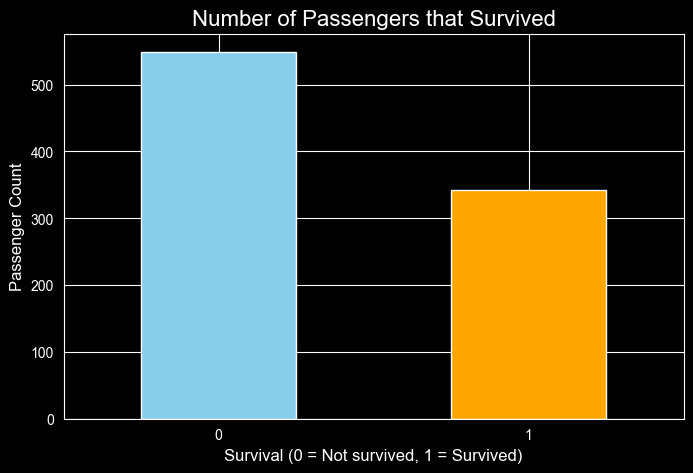

In [6]:
# Plot number of passengers that survived
fig1, ax1 = plt.subplots(figsize=(8, 5))
overall_survival_counts = train_df["Survived"].value_counts(sort=False)
overall_survival_counts.plot(kind="bar", color=["skyblue", "orange"], ax=ax1)
ax1.set_title("Number of Passengers that Survived", fontsize=16)
ax1.set_xlabel("Survival (0 = Not survived, 1 = Survived)", fontsize=12)
ax1.set_ylabel("Passenger Count", fontsize=12)
ax1.tick_params(axis="x", rotation=0)


Depicts the amount of survivors v not survivors...

We are going to do a bar plot to show if survival rates differ between genders, which can reveal trends or inequalities in survival.

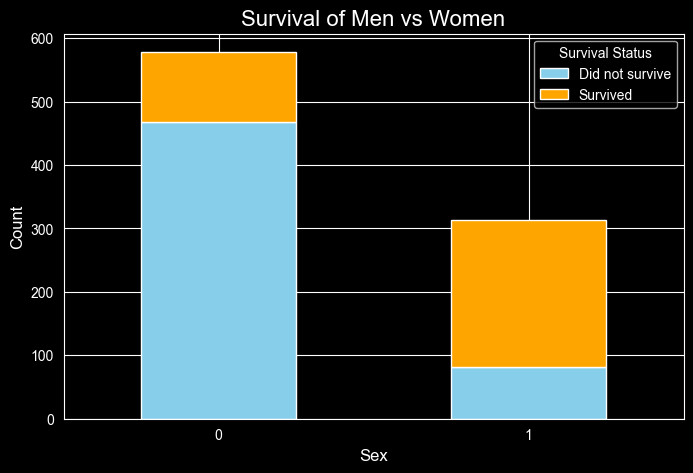

In [7]:
# Group by 'Sex' and 'Survived', then count occurrences
survival_counts = train_df.groupby(["Sex", "Survived"]).size().unstack()

# Plot a bar chart for survival by gender
fig2, ax2 = plt.subplots(figsize=(8, 5))
survival_counts.plot(kind="bar", stacked=True, color=["skyblue", "orange"], ax=ax2)
ax2.set_title("Survival of Men vs Women", fontsize=16)
ax2.set_xlabel("Sex", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.legend(["Did not survive", "Survived"], title="Survival Status")
ax2.tick_params(axis="x", rotation=0)


It is apparent that females had a much higher survival rate, this is probably due to most men sacrificing their spot on lifeboats in exchange for the women, as during the societal standards during when the titanic sank. Furthermore it is also likely that men also attempted to save women by returning back to get their lovers, wives, daughters, etc. which would have further reduced their chances of survival.

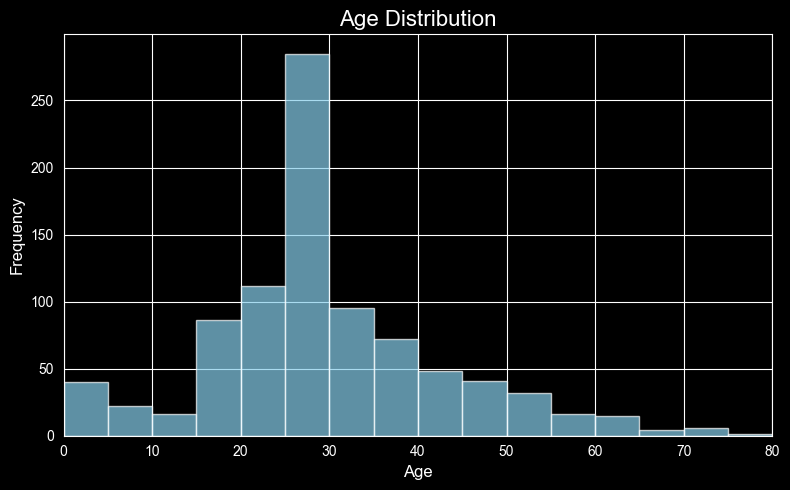

In [8]:
# Shared bins keep both histograms aligned and avoid off-center appearance.
age_bins = list(range(0, 85, 5))

fig4, ax4 = plt.subplots(figsize=(8, 5))
train_df["Age"].plot(kind="hist", bins=age_bins, alpha=0.7, color="skyblue", ax=ax4)
ax4.set_title("Age Distribution", fontsize=16)
ax4.set_xlabel("Age", fontsize=12)
ax4.set_ylabel("Frequency", fontsize=12)
ax4.set_xlim(0, 80)
ax4.set_xticks(range(0, 81, 10))
plt.tight_layout()


Disregarding the scew in the middle due to the median, it is also apparent that most passenges on the ship is between the age of 10 and 40, which is due to the fact that most passengers likely brought along their partners, therefore adding to the number of individuals in that population. Furthermore during that time, the average life span was about 50-60 years therefore highly restricting the amount of people that were to be older than that.

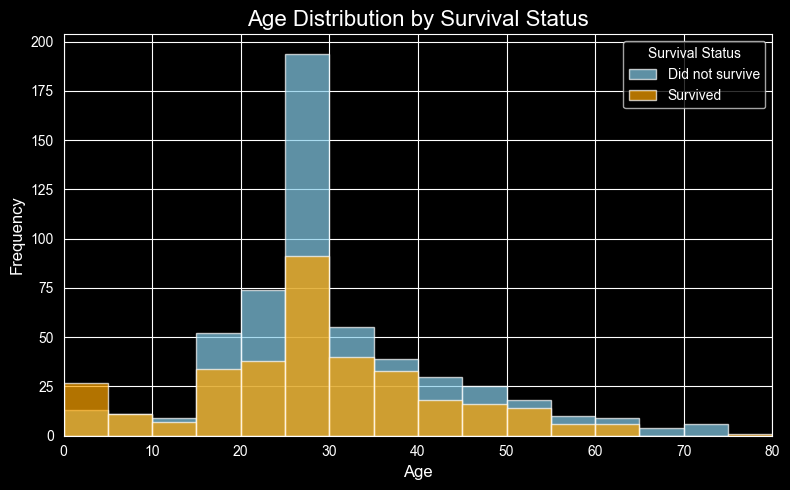

In [9]:
fig5, ax5 = plt.subplots(figsize=(8, 5))
train_df[train_df["Survived"] == 0]["Age"].plot(
    kind="hist", bins=age_bins, alpha=0.7, color="skyblue", ax=ax5
)
train_df[train_df["Survived"] == 1]["Age"].plot(
    kind="hist", bins=age_bins, alpha=0.7, color="orange", ax=ax5
)
ax5.set_title("Age Distribution by Survival Status", fontsize=16)
ax5.legend(["Did not survive", "Survived"], title="Survival Status")
ax5.set_xlabel("Age", fontsize=12)
ax5.set_ylabel("Frequency", fontsize=12)
ax5.set_xlim(0, 80)
ax5.set_xticks(range(0, 81, 10))
plt.tight_layout()


To begin, the medium filling we did for the missing and outlier data has influenced our graph, therefore at the medium age from 25-30 has spiked up to significantly more than the rest. This is due to the extreme and missing data still having the data for whether they survived or not. Furthmore, it is apparant that below 10, there is an high amount of survivors, signifcantly outpacing those who died. In contrast, basically noone above 65 survived, this is a likely due to their advanced age that influenced how likely they were able to survive not only the cold and harsh conditions but also escape in time.


Boxplots for ages of survivors and non-survivors

Text(0, 0.5, 'Age')

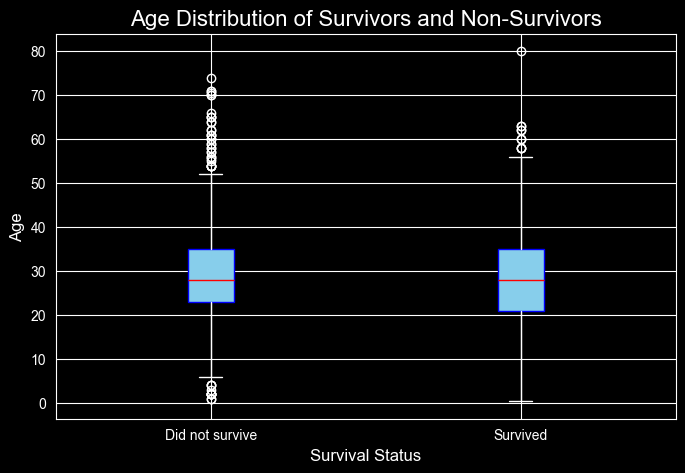

In [10]:
fig7, ax7 = plt.subplots(figsize=(8, 5))
survived_ages = [
    train_df[train_df["Survived"] == 0]["Age"],
    train_df[train_df["Survived"] == 1]["Age"],
]
ax7.boxplot(
    survived_ages,
    tick_labels=["Did not survive", "Survived"],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue"),
    medianprops=dict(color="red"),
)
ax7.set_title("Age Distribution of Survivors and Non-Survivors", fontsize=16)
ax7.set_xlabel("Survival Status", fontsize=12)
ax7.set_ylabel("Age", fontsize=12)


Looking at the boxplot, first thing that is noticed is that q1 for survived is lower than q1 for not survived, therefore it can be interpereted that more younger people survived. Furthermore, the outliers for did not survive are all between 0 and the minimum, implicating those under the minimum should've survived as not surviving would have been an outlier. Furthermore the same can be seen for survived, as for people over 60, the data implies that they should've not survived -> Being outliers instead of within the maximum. Adding onto this, q1 is significantly higher on did not survive compared to survived, furthering my original case that those under the age should be expected to survive.

## Investigation tasks

**Task 1**: a visualization alone is not inherently valuable, its true usefulness lies in the insights we can extract from it. Based on the visualizations provided in Step 3, analyse and interpret each one, focusing on how different features may influence (if they do) the likelihood of survival on the Titanic. For each graph, provide at least two insightful sentences that explain the observed trends and their potential impact on survival rates.

<span style="color:red">(6 marks)</span>

<span style="color:red">
Your answer goes here</span>
Answers below each graph, sorry...

**Task 2**: determine and justify which type of graph would be most effective in analyzing the correlation between passenger class and the likelihood of survival on the Titanic. 

<span style="color:red">(2 marks)</span>

A bar plot would be most likely to determine the correlation between passenger class and the likelihood of survival, this is due to the fact that passenger class is a categorical variable and not numerical. Doing so would easily display the percentages of survival and in due course allow a human to interpret the data and such correlations.

**Task 3**: create the specified graph to analyze the correlation between passenger class and the likelihood of survival on the Titanic. You may use AI tools to generate the code for visualization, but the interpretation of the results should be your own.

<span style="color:red">(2 marks)</span>

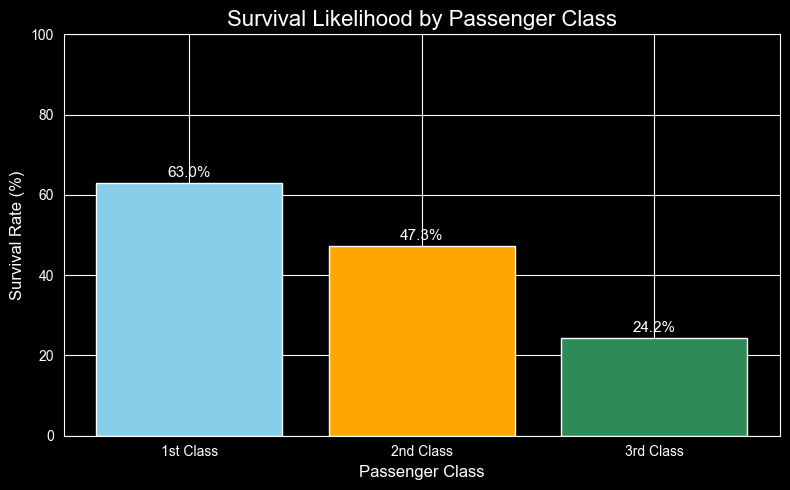

In [11]:
# Task 3: Survival likelihood by passenger class
fig6, ax6 = plt.subplots(figsize=(8, 5))

survival_rate_by_class = (
    train_df.groupby("Pclass")["Survived"].mean().sort_index() * 100
)

class_labels = ["1st Class", "2nd Class", "3rd Class"]

ax6.bar(class_labels, survival_rate_by_class.values, color=["skyblue", "orange", "seagreen"])
ax6.set_title("Survival Likelihood by Passenger Class", fontsize=16)
ax6.set_xlabel("Passenger Class", fontsize=12)
ax6.set_ylabel("Survival Rate (%)", fontsize=12)
ax6.set_ylim(0, 100)

for i, value in enumerate(survival_rate_by_class.values):
    ax6.text(i, value + 1.5, f"{value:.1f}%", ha="center", fontsize=11)

plt.tight_layout()

Based on the code, it is understood that 1st class passengers had the highest survival rate, followed by 2nd class and then 3rd class. The Titanic was layed out in a manner to which the 1st class passengers were suited on higher decks, therefore could access a variety of routes and could also get to life boats faster. In contrast, 3rd class passengers were positioned lower in the ship, therefore they had lackluster access to escape routes and would've approached the lifeboats later. Such logic also applies to 2nd class.

**Bonus**: create a scatter plot and a treemap using the Titanic dataset, then analyse and interpret the results. Explain the insights each visualization provides, including any trends, patterns, or relationships observed in the data.

<span style="color:red">(1 mark)</span>

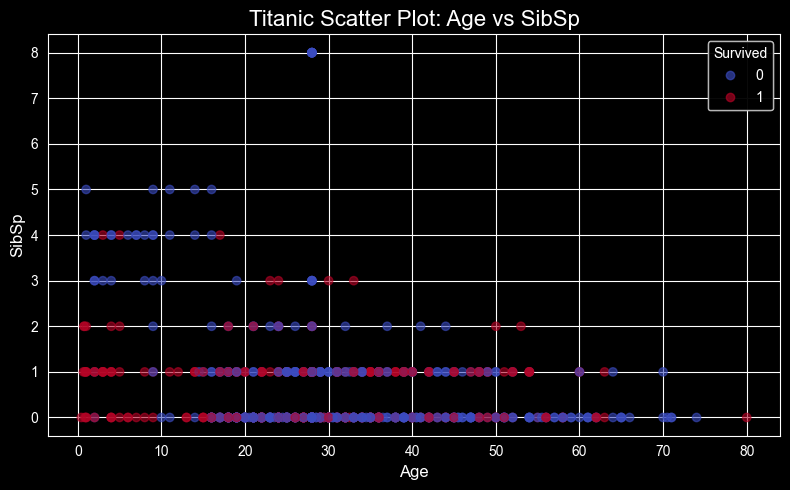

In [12]:
# Bonus: Scatter plot (Age vs available numeric feature, colored by survival)
# AI GENERATED
scatter_y_candidates = ["Fare", "SibSp", "Parch", "Pclass"]
scatter_y_col = next((col for col in scatter_y_candidates if col in train_df.columns), None)

if scatter_y_col is None:
    raise ValueError("No suitable y-axis column found for bonus scatter plot.")

bonus_scatter_df = train_df.dropna(subset=["Age", scatter_y_col, "Survived"])

fig8, ax8 = plt.subplots(figsize=(8, 5))
scatter = ax8.scatter(
    bonus_scatter_df["Age"],
    bonus_scatter_df[scatter_y_col],
    c=bonus_scatter_df["Survived"],
    cmap="coolwarm",
    alpha=0.6,
)
ax8.set_title(f"Titanic Scatter Plot: Age vs {scatter_y_col}", fontsize=16)
ax8.set_xlabel("Age", fontsize=12)
ax8.set_ylabel(scatter_y_col, fontsize=12)
legend1 = ax8.legend(*scatter.legend_elements(), title="Survived")
ax8.add_artist(legend1)
plt.tight_layout()


For the graph of how sibling counts can affect survival rate, it can be observed that for sibling count of 0, there are more survivors than of those who did not. In contrast however, for those with only one sibling, the suvival rate is slightly lower, this can be interpereted as those with one sibling, chosing to save their siblings instead of themselves, therefore resulting in lower survival rates. Beyond 1 however like in the case of 2 3 4 5 and 8, it can be seen that as sibling count increases survival rates does so to, this could be associated with the siblings, of more than 2 wishing to survive together, therfore assisting each other instead of the rest of the passengers onboard the Titanic. Doing such would increase their survival rates.

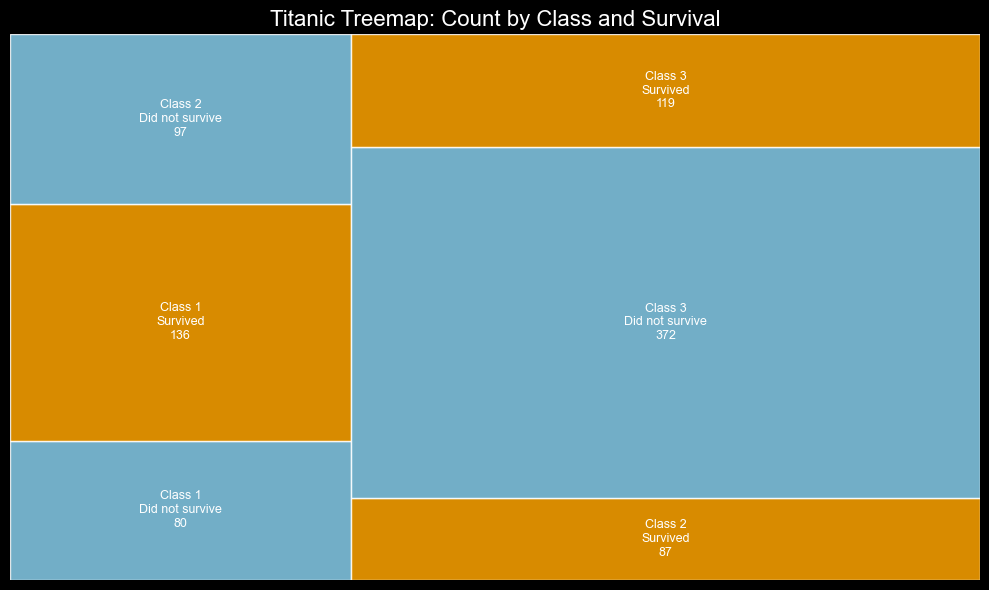

In [13]:
# Bonus: Treemap (Passenger count by class and survival status)
# AI GENERATED
bonus_treemap_df = (
    train_df.groupby(["Pclass", "Survived"]).size().reset_index(name="Count")
)
bonus_labels = bonus_treemap_df.apply(
    lambda row: (
        f"Class {int(row['Pclass'])}\n"
        f"{'Survived' if int(row['Survived']) == 1 else 'Did not survive'}\n"
        f"{int(row['Count'])}"
    ),
    axis=1,
)
bonus_colors = [
    "orange" if int(survived) == 1 else "skyblue"
    for survived in bonus_treemap_df["Survived"]
]

fig9, ax9 = plt.subplots(figsize=(10, 6))

try:
    import squarify

    squarify.plot(
        sizes=bonus_treemap_df["Count"],
        label=bonus_labels,
        color=bonus_colors,
        alpha=0.85,
        ax=ax9,
        text_kwargs={"fontsize": 9},
    )
    ax9.set_title("Titanic Treemap: Count by Class and Survival", fontsize=16)
    ax9.axis("off")
except ImportError:
    ax9.text(
        0.5,
        0.5,
        "Install squarify to render the treemap:\npip install squarify",
        ha="center",
        va="center",
        fontsize=11,
    )
    ax9.set_axis_off()

plt.tight_layout()


From this treemap, it can be seen that the survival rates for class one are significantly higher than for the other class, this can be known due to the size of class 1 compared to class 2 and class 3. Furthermore, as the treemap clearly depicts — the survival rate for the other two are significantly lower. Adding onto this, the survival rates for class 2 is lower than class one with class 3 having the lowest survival rates. This is most likely due to class 1 having more access to escaper routes and earlier access to life boats in juxtaposition to class 2 and 3 which would've had difficluties reaching such lifeboats and finding escape routes